# Unsupervised Learning (II): Dimensionality Reduction

<div class='alert alert-info'>

:::{objectives}
- Understand motivation for dimensionality reduction, and representative methods (PCA, t-SNE, UMAP) to reduce dimensionalities in datasets.
- Describe idea of PCA (linear method that keeps most variance), apply PCA to correlate features with components, interpret explained variance ratio, and decide how many components to keep.
- Recognize t-SNE and UMAP as nonlinear methods for complex data visualization.
- Apply PCA, t-SNE, and UMAP to Penguins and MNIST datasets to evaluate their performance in reducing dimensionality while retaining essential information for clustering.
:::
</div

<div class='alert alert-success'>

:::{instructor-note}
- 40 min teaching
- 30 min exercises/discussion
:::
</div>

## 1. From Clustering to Dimensionality Reduction: Simplifying Complexity

In episode [Unsupervised Learning (I): Clustering](./7-clustering.ipynb), we talked about clustering, which is a core unsupervised ML technique that groups similar data points into clusters based on their features, without requiring labeled data.
- fundamental value of clustering lies in its ability to reveal segments and patterns that are not immediately obvious, with applications ranging from customer segmentation in marketing to anomaly detection in network security
- despite its usefulness, clustering comes with notable limitations
	- a major challenge is determining appropriate number of clusters in advance, as in K-Means, where results can vary depending on initialization
	- clustering results are highly sensitive to choice of distance metric and scaling of features, which can significantly alter outcomes
	- furthermore, clustering often struggles with high-dimensional data due to **curse of dimensionality**, where distance measures lose their discriminative power, making it harder to identify meaningful groups
	- given these challenges, especially around data sensitivity and interpretability, it is often crucial to preprocess data with another form of unsupervised learning before clustering: **dimensionality reduction**
- **where clustering seeks to group samples, dimensionality reduction focuses on simplifying feature space itself**
	- by transforming a high-dimensional dataset into a lower-dimensional subspace while preserving its most critical relationships, dimensionality reduction can mitigate noise, reduce computational cost, and reveal most discriminative features that define data's structure
	- this process not only addresses clustering's sensitivity to irrelevant features but also provides a powerful foundation for visualizing potential clusters in 2D or 3D, making entire analytical process more robust and insightful
- methods such as **PCA** (Principal Component Analysis), **t-SNE** (t-Distributed Stochastic Neighbor Embedding), and **UMAP** (Uniform Manifold Approximation and Projection) make data more manageable, reduce noise, and improve clustering performance

Penguins dataset includes multiple features (bill length, bill depth, flipper length, body mass, species labels, *etc.*), plotting it directly in 2D can make it difficult to capture all relationships and structures hidden in dataset
- that is why we plot pairplots between all pair of features to achieve a clear visualization of their correlations
- here we apply dimensionality reduction to this dataset
- goal is to take dataset’s multiple features, and project them into a simpler, lower-dimensional space for a better visualization
    - this process not only helps us better understand data but also prepares it for downstream tasks, such as clustering or classification, by reducing noise and highlighting most informative aspects of dataset.

## 2. Load Dataset & Data Preparation

Following the procedures used in previous episodes, we apply the same preprocessing steps to the Penguins dataset, including handling missing values and detecting outliers. For the clustering task, categorical features are not required, so encoding them is unnecessary.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

penguins = sns.load_dataset('penguins')
penguins_dimR = penguins.dropna()
penguins_dimR.duplicated().value_counts()

species = penguins_dimR["species"]

from sklearn.preprocessing import StandardScaler

X = penguins_dimR[['bill_length_mm', 'bill_depth_mm', 'flipper_length_mm', 'body_mass_g']]

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

## 3. Principal Component Analysis

### 3.1 What is PCA

PCA is an orthogonal linear transformation used to reduce dimensionality of data while preserving as much variability as possible
- it is achieved by transforming original variables into a new set of uncorrelated variables called **principal components** (**PCs**)
- each PC is a **linear** combination of original variables, and they are ordered such that 1st few retain most of variation present in original variables
- PCA is very useful for two major purposes:
    - **visualization**
    	- projecting a high-dimensional space into 2D/3D
    	- using graphical visualizations, we can have insights about distribution of instances and look at how separable instances from different classes are
    - **feature selection**
    	- since PCA can transform instances from high to lower dimensions, we could use this method to address **curse of dimensionality**
    	- instead of learning from original set of features, we can transform our instances with PCA and then apply a learning algorithm on top of new feature space

### 3.2 Build a PCA model

When reducing Penguins dataset from 4D, a natural question arises: how many components are needed to retain sufficient information from original dataset?
- we start with a simple task of preserving full variance by transforming Penguins dataset, which contains four numerical features, into a new dataset with four PCs
- in this way, all information from original dataset is fully retained in new representation
- we create a model `pca_4` using `PCA` class from `sklearn.decomposition`, specifying that `X_scaled` data should be converted into a new dataset with four PCs

In [2]:
from sklearn.decomposition import PCA

# build a new PCA model with 4 PCs
pca_penguin = PCA(n_components=4)
X_pca_penguin = pca_penguin.fit_transform(X_scaled)

explained_var_penguin = pca_penguin.explained_variance_ratio_
print(f'''The explained variance of PC1 is {explained_var_penguin[0]:.2%}
The explained variance of PC2 is {explained_var_penguin[1]:.2%}
The explained variance of PC3 is {explained_var_penguin[2]:.2%}
The explained variance of PC4 is {explained_var_penguin[3]:.2%}\n
The explained variance of ALL is {explained_var_penguin.sum():.2%}''')

The explained variance of PC1 is 68.63%
The explained variance of PC2 is 19.45%
The explained variance of PC3 is 9.22%
The explained variance of PC4 is 2.70%

The explained variance of ALL is 100.00%


Term `explained variance ratio` tells us how much of total variability in original Penguins dataset is captured by each PC.
- 1st PC has an explained variance ratio of 0.69, which means that 69% of variability in Penguins dataset can be represented by this single component.
- 1st two PCs can retain approximately 90% of information from original Penguins dataset.

What does the data in two principal components represent?
- When we have two components, 
	- PC1 is the direction in feature space along which the data varies the most,
	- PC2 is the direction orthogonal to PC1 that captures the next largest variance.
- When we have three components, PC3 captures the next largest source of variance, orthogonal to both PC1 and PC2.
	- In such a situation, we have to use 3D visualization to visualize the three components.
- When we have four componnents, PC4 captures the next largest source of variance, orthogonal to both PC1, PC2, and PC3.
	- It is difficult for us to visualize the four dimensional space.

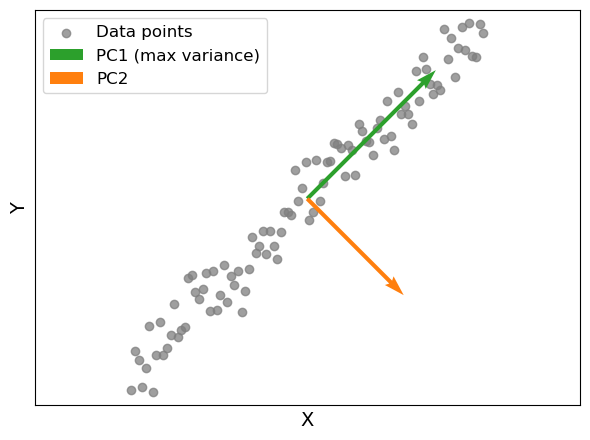

In [2]:
from IPython.display import Image, display
display(Image("../images/dimensionality-reduction/pca-data-representation.png", width=1024))

In [3]:
# create DataFrame for PCA results
pca_penguin_columns = [f'PC_{i+1}' for i in range(X_pca_penguin.shape[1])]
X_pca_penguin_add_PCs = pd.DataFrame(X_pca_penguin, columns=pca_penguin_columns, index=X.index)

# concatenate with original DataFrame
X_penguin_add_PC4 = pd.concat([X, X_pca_penguin_add_PCs], axis=1)
X_penguin_add_PC4

,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,PC_1,PC_2,PC_3,PC_4
0,39.1,18.7,181.0,3750.0,-1.853593,0.032069,-0.234902,-0.528397
1,39.5,17.4,186.0,3800.0,-1.316254,-0.443527,-0.027470,-0.401727
2,40.3,18.0,195.0,3250.0,-1.376605,-0.161230,0.189689,0.528662
4,36.7,19.3,193.0,3450.0,-1.885288,-0.012351,-0.628873,0.472893
5,39.3,20.6,190.0,3650.0,-1.919981,0.817598,-0.701051,0.196416
...,...,...,...,...,...,...,...,...
338,47.2,13.7,214.0,4925.0,1.997716,-0.976771,0.379425,-0.160892
340,46.8,14.3,215.0,4850.0,1.832651,-0.784510,0.240758,0.008955
341,50.4,15.7,222.0,5750.0,2.751505,0.266556,-0.419306,-0.236256
342,45.2,14.8,212.0,5200.0,1.713854,-0.725875,-0.262764,-0.330004


Correlations between original variables (features) andb new PCs are described by `corr_var_comp`, which qualifies how strongly each original variable contributes to a PC
- `corr_var_comp` ranges from -1 to 1
- +1 means a perfect positive correlation betweenbvariable and component.
- 0 indicates no linear correlation, and component does not explain that variable at all.
- -1 suggests a perfect negative correlation


In [4]:
cp_variables = X_penguin_add_PC4.columns

n_variables = pca_penguin.n_features_in_

# calculate the covariance matrix between veriables and Components
cov_var_comp = X_penguin_add_PC4.cov()
cov_var_comp = cov_var_comp.iloc[:pca_penguin.n_features_in_, pca_penguin.n_features_in_:]

# calculate the correlation matrix between variables and Components
corr_var_comp = X_penguin_add_PC4.corr()
corr_var_comp = corr_var_comp.iloc[:pca_penguin.n_features_in_, pca_penguin.n_features_in_:]

corr_var_comp

,PC_1,PC_2,PC_3,PC_4
bill_length_mm,0.751829,0.529438,0.390097,-0.047682
bill_depth_mm,-0.661186,0.702309,-0.258529,0.052522
flipper_length_mm,0.955748,0.005106,-0.143347,0.256849
body_mass_g,0.910762,0.067449,-0.359279,-0.192045


In practical applications, square of correlation between a variable and a component is often denoted cos² (cosine squared)
- cosine of angle between variable vector and component axis tells you how much of variable’s variance is explained by that component
- squaring it gives proportion of variance of that variable explained by component, hence cos²
- we square `corr_var_comp` to get proportion of each variable’s variance explained by each PC
    - figure below allows us to examine and visualize in detail how each original penguine feature contributes to four PCs
    - each PC is a **linear** combination of original features and can be expressed mathematically as
	- $PC1_i = w_1 * bill\_length_i + w_2 * bill\_depth_i + w_3 * flipper\_length_i + w_4 * body\_mass_i$

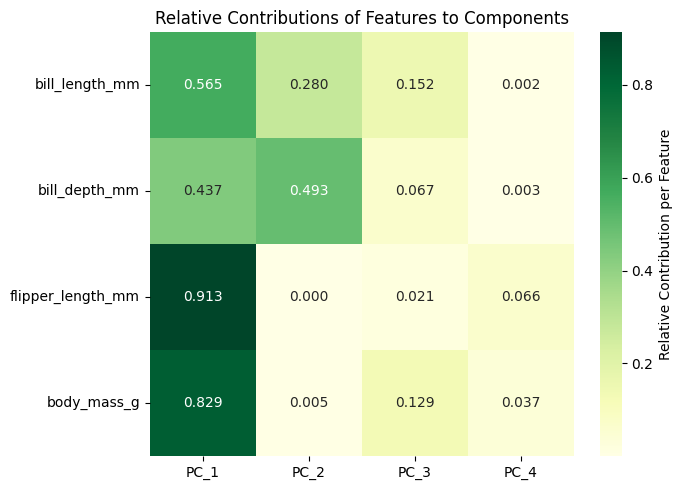

In [5]:
cos2 = corr_var_comp**2

# normalize the cos2 matrix by row (each row sums to 1)
cos2_normalized = cos2.div(cos2.sum(axis=1), axis=0)

# plot the normalized heatmap
plt.figure(figsize=(7, 5))
heatmap = sns.heatmap(cos2_normalized,
                      annot=True,
                      fmt=".3f",
                      cmap='YlGn',
                      cbar_kws={'label': 'Relative Contribution per Feature'})
plt.title('Relative Contributions of Features to Components')
plt.tight_layout()
plt.show()

<div class='alert alert-warning'>

:::{discussion} **How many PCs are truly necessary to represent dataset effectively?**
:class: dropdown

- there is no single fixed number of PCs that is always "necessary"
- instead, number of PCs we should keep depends on how much variance we want to preserve and how much structure in data is meaningful for our task
- some tips to reserve PCs
	- look at the explained variance ratio
		- cumulative variance >= 90% is often used in scientific data, imaging, chemistry, biology:
		- cumulative variance >= 95% is good when noise is high
		- cumulative variance >= 99% is used for lossless compression-like scenarios
	- use "elbow method"
		- plot eigenvalues (variance explained by each PC) and cumulative variance curve
		- if see a sharp drop then a plateau, then hoose number of PCs at "elbow", where adding more components yields minimal additional variance
	- consider downstream task performance
	- noise structure matters
		- if dataset contains many noisy or redundant variables, PCA will compress strongly, meaning that only a few PCs may be meaningful, and remaining PCs mostly capture noise
- practical rule of thumb - 1
	- when you don’t know dataset yet
	- keep enough PCs to capture 90–95% variance
	- expect somewhere between 5–50 PCs for most real datasets
- practical rule of thumb - 2
    - fewer components → lower-dimensional representation → some information is lost, but main patterns remain
    - more components → higher-dimensional representation → more information retained
:::
</div>

In [6]:
X_penguin_add_PC4_categorical = pd.concat([penguins_dimR[["species", 'island', 'sex']], X_penguin_add_PC4], axis=1)
X_penguin_add_PC4_categorical

,species,island,sex,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,PC_1,PC_2,PC_3,PC_4
0,Adelie,Torgersen,Male,39.1,18.7,181.0,3750.0,-1.853593,0.032069,-0.234902,-0.528397
1,Adelie,Torgersen,Female,39.5,17.4,186.0,3800.0,-1.316254,-0.443527,-0.027470,-0.401727
2,Adelie,Torgersen,Female,40.3,18.0,195.0,3250.0,-1.376605,-0.161230,0.189689,0.528662
4,Adelie,Torgersen,Female,36.7,19.3,193.0,3450.0,-1.885288,-0.012351,-0.628873,0.472893
5,Adelie,Torgersen,Male,39.3,20.6,190.0,3650.0,-1.919981,0.817598,-0.701051,0.196416
...,...,...,...,...,...,...,...,...,...,...,...
338,Gentoo,Biscoe,Female,47.2,13.7,214.0,4925.0,1.997716,-0.976771,0.379425,-0.160892
340,Gentoo,Biscoe,Female,46.8,14.3,215.0,4850.0,1.832651,-0.784510,0.240758,0.008955
341,Gentoo,Biscoe,Male,50.4,15.7,222.0,5750.0,2.751505,0.266556,-0.419306,-0.236256
342,Gentoo,Biscoe,Female,45.2,14.8,212.0,5200.0,1.713854,-0.725875,-0.262764,-0.330004


After transforming Penguins dataset from four features to four PCs, we project data onto any pair of PCs for visualization

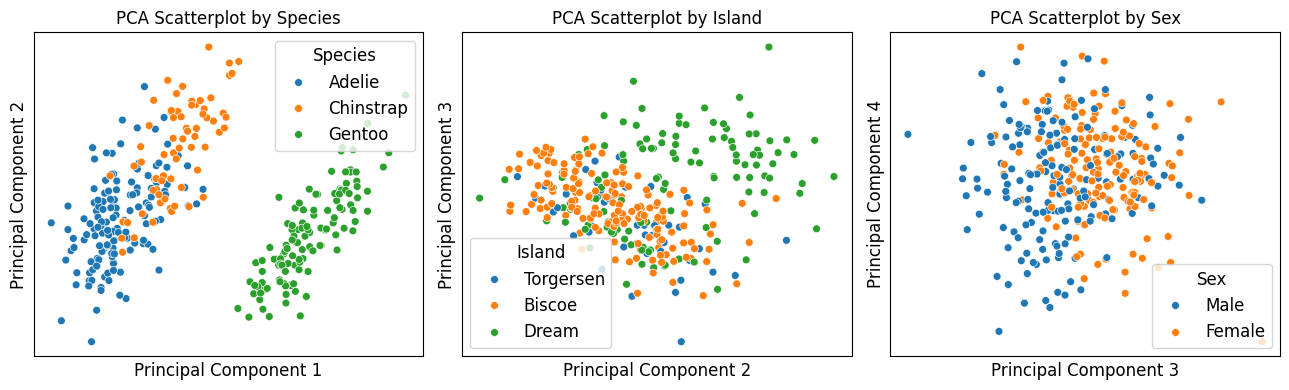

In [7]:
fig, axes = plt.subplots(1, 3, figsize=(13,4))

# left subpolt: hua by species
sns.scatterplot(data=X_penguin_add_PC4_categorical, x='PC_1', y='PC_2', hue='species', s=32, ax=axes[0])
axes[0].set_title("PCA Scatterplot by Species", fontsize=12)
axes[0].set_xlabel("Principal Component 1", fontsize=12)
axes[0].set_ylabel("Principal Component 2", fontsize=12)
axes[0].legend(title="Species", fontsize=12, title_fontsize=12)
axes[0].set_xticks([])
axes[0].set_yticks([])

# middle subplot: hue by island
sns.scatterplot(data=X_penguin_add_PC4_categorical, x='PC_2', y='PC_3', hue='island', s=32, ax=axes[1])
axes[1].set_title("PCA Scatterplot by Island", fontsize=12)
axes[1].set_xlabel("Principal Component 2", fontsize=12)
axes[1].set_ylabel("Principal Component 3", fontsize=12)
axes[1].legend(title="Island", fontsize=12, title_fontsize=12)
axes[1].set_xticks([])
axes[1].set_yticks([])

# right subplot: hue by sex
sns.scatterplot(data=X_penguin_add_PC4_categorical, x='PC_3', y='PC_4', hue='sex', s=32, ax=axes[2])
axes[2].set_title("PCA Scatterplot by Sex", fontsize=12)
axes[2].set_xlabel("Principal Component 3", fontsize=12)
axes[2].set_ylabel("Principal Component 4", fontsize=12)
axes[2].legend(title="Sex", fontsize=12, title_fontsize=12)
axes[2].set_xticks([])
axes[2].set_yticks([])

plt.tight_layout()
plt.show()

### 3.3 Correlation circle

To gain deeper insight into how original variables relate to principal components, we can use a **correlation circle**, also known as a **variable factor map**
- this graphical tool provides a visual representation of contribution and correlation of each original variable with components
- in a 2D PCA plot (PC1 *vs.* PC2 in left subplot, and PC3 *vs.* PC4 in right subplot), each original feature is represented as a vector (arrow) pointing from origin
    - direction of arrow indicates whether variable (feature) is positively or negatively correlated with principal components
    - length of arrow indicates strength of correlation --- longer arrows mean variable (feature) contributes strongly to components
    - circle itself (radius = 1) represents maximum possible correlation between a variable (feature) and components, since PCA projects standardized variables (features)
- in addition, correlations between variables (features) can also be specified
	- variables (features) pointing in similar directions are positively correlated (body mass and flipper length), that is why we performed regression task using these two features
	- variables (features) pointing in opposite directions are negatively correlated (for specific pairs of components)
	- variables (features) at roughly 90° to each other are nearly uncorrelated

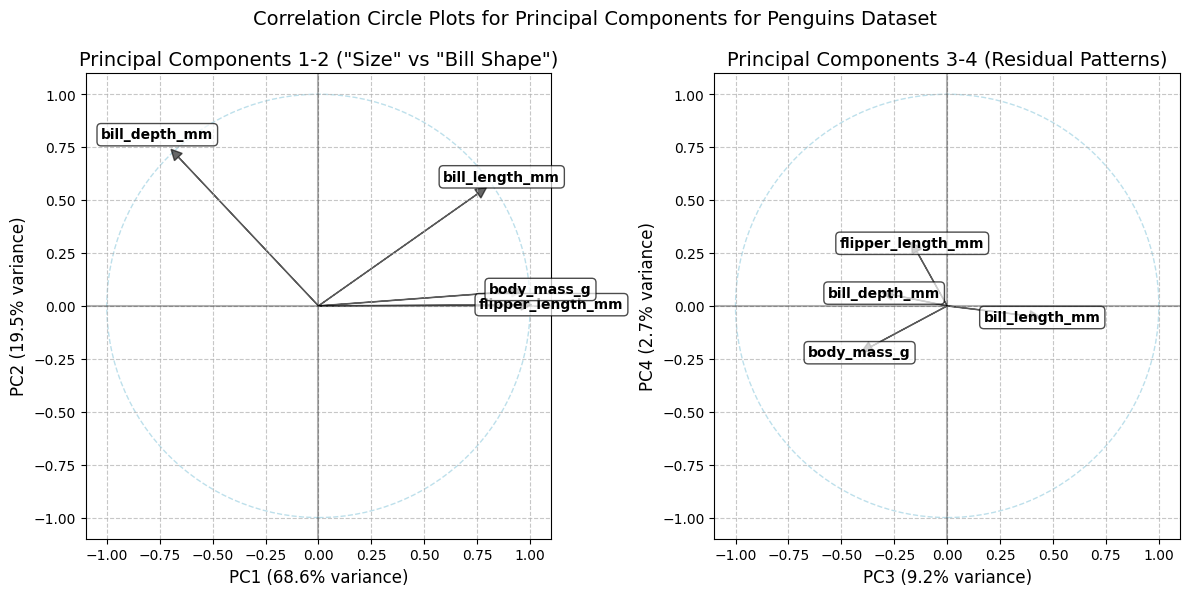

In [8]:
# create loadings DataFrame (correlations between variables and components)

loadings = pca_penguin.components_.T * np.sqrt(pca_penguin.explained_variance_)
loadings_df = pd.DataFrame(loadings, 
                           columns=[f'PC{i+1}' for i in range(4)], # n_components
                           index=X.columns)

# create a figure with two subplots side by side
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 6))
fig.suptitle('Correlation Circle Plots for Principal Components for Penguins Dataset', fontsize=14)

# cunction to create a correlation circle on a given axis
def plot_correlation_circle(loadings, pc_x, pc_y, ax, title):
    # set the aspect ratio to equal for a perfect circle
    ax.set_aspect('equal', adjustable='box')
    
    # create a unit circle
    circle = plt.Circle((0, 0), 1, color='lightblue', fill=False, linestyle='--', alpha=0.8)
    ax.add_patch(circle)
    
    # plot arrows and labels for each variable
    for i, feature in enumerate(loadings.index):
        x = loadings.loc[feature, pc_x]
        y = loadings.loc[feature, pc_y]
        
        # plot arrow
        ax.arrow(0, 0, x, y, head_width=0.05, head_length=0.05, fc='k', ec='k', alpha=0.6)
        
        # plot label (offset slightly from the arrow tip)
        ax.text(x * 1.15, y * 1.15, feature, ha='center', va='center', 
                fontweight='bold', fontsize=10,
                bbox=dict(facecolor='white', alpha=0.7, boxstyle='round,pad=0.3'))

    ax.axhline(y=0, color='k', linestyle='-', alpha=0.3)
    ax.axvline(x=0, color='k', linestyle='-', alpha=0.3)

    ax.set_xlim(-1.1, 1.1)
    ax.set_ylim(-1.1, 1.1)
    
    # calculate variance explained for the specific components
    pc_x_idx = int(pc_x[2:]) - 1  # Extract number from 'PC1' -> 0
    pc_y_idx = int(pc_y[2:]) - 1  # Extract number from 'PC2' -> 1
    
    ax.set_xlabel(f'{pc_x} ({pca_penguin.explained_variance_ratio_[pc_x_idx]:.1%} variance)', 
                 fontsize=12)
    ax.set_ylabel(f'{pc_y} ({pca_penguin.explained_variance_ratio_[pc_y_idx]:.1%} variance)', 
                 fontsize=12)
    ax.set_title(title, fontsize=14)
    ax.grid(True, linestyle='--', alpha=0.7)

# PC1 vs PC2
plot_correlation_circle(loadings_df, 'PC1', 'PC2', ax1, 'Principal Components 1-2 ("Size" vs "Bill Shape")')

# PC3 vs PC4
plot_correlation_circle(loadings_df, 'PC3', 'PC4', ax2, 'Principal Components 3-4 (Residual Patterns)')

plt.tight_layout()
plt.subplots_adjust(top=0.9)
plt.show()

## 4. t-Distributed Stochastic Neighbor Embedding (t-SNE)

Since PCA is based on linear combinations of all features, it has some inherent limitations
- in particular, it may fail to capture complex, non-linear relationships in data, and it primarily focuses on maximizing global variance, which can overlook subtle local structures, intricate clusters, or hierarchical patterns -- that are quite common in real-world datasets
- to address these challenges, we move beyond linear methods and explore advanced non-linear dimensionality reduction techniques. 
Algorithms such as **t-SNE** (t-Distributed Stochastic Neighbor Embedding) and **UMAP** (Uniform Manifold Approximation and Projection) are particularly effective in capturing non-linear patterns in dataset.
	- These methods are designed to preserve local neighborhood relationships, revealing intricate patterns that PCA might miss and providing a more detailed view of the underlying structure of the penguin population.

### 4.1 What is t-SNE

t-SNE is a powerful dimensionality reduction technique primarily used for visualizing high-dimensional data in 2D or 3D
- main idea of t-SNE is to preserve local structure of data, meaning that points that are close in high-dimensional space remain close in lower-dimensional embedding
- that is, it models pairwise similarities between data points in both high-dimensional and low-dimensional spaces

### 4.2 Build a t-SNE model

We build a t-SNE model with 2 PCs using `TSNE` class in `sklearn.manifold`
- hyperparameter `perplexity` controls number of effective neighbors each point considers when learning embedding
	- higher values emphasize global structure, lower values emphasize local relationships

In [9]:
from sklearn.manifold import TSNE

# build a t-SNE model with 2 PCs
tsne_penguin = TSNE(n_components = 2, perplexity = 50)
X_tsne_penguin = tsne_penguin.fit_transform(X_scaled)

X_tsne_penguin_species = penguins_dimR.join(pd.DataFrame(X_tsne_penguin, 
                            index = penguins_dimR.index,
                            columns = ['PC_1', 'PC_2']))
X_tsne_penguin_species

,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex,PC_1,PC_2
0,Adelie,Torgersen,39.1,18.7,181.0,3750.0,Male,-12.583183,1.296008
1,Adelie,Torgersen,39.5,17.4,186.0,3800.0,Female,-10.202713,1.233770
2,Adelie,Torgersen,40.3,18.0,195.0,3250.0,Female,-8.527937,1.971435
4,Adelie,Torgersen,36.7,19.3,193.0,3450.0,Female,-12.553984,-0.584580
5,Adelie,Torgersen,39.3,20.6,190.0,3650.0,Male,-13.948335,-2.829005
...,...,...,...,...,...,...,...,...,...
338,Gentoo,Biscoe,47.2,13.7,214.0,4925.0,Female,27.998510,2.550709
340,Gentoo,Biscoe,46.8,14.3,215.0,4850.0,Female,27.374943,2.283183
341,Gentoo,Biscoe,50.4,15.7,222.0,5750.0,Male,22.121027,4.712508
342,Gentoo,Biscoe,45.2,14.8,212.0,5200.0,Female,26.795017,3.393671


After fitting the t-SNE model, we can visualize the Penguin dataset in two dimensions, allowing us to explore the relationships between individual data points, identify potential clusters, and observe how different species are distributed across the embedding.

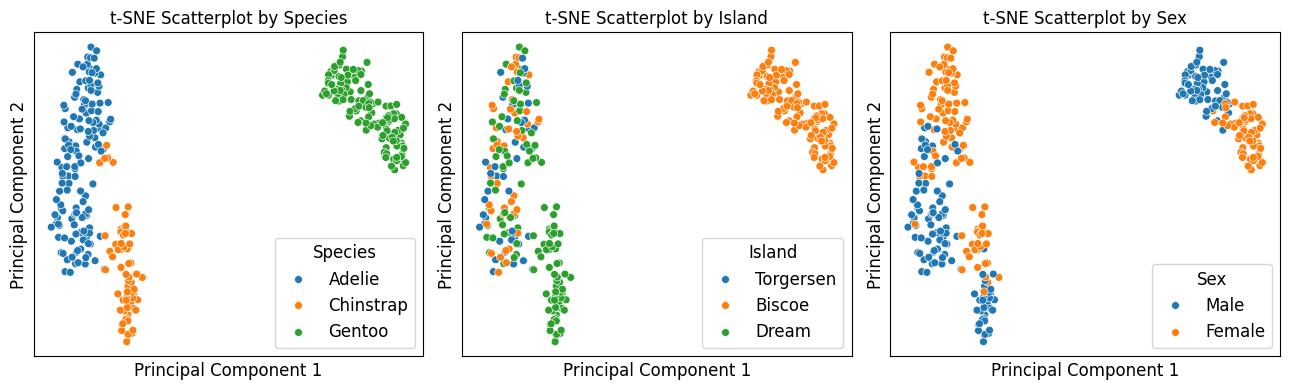

In [10]:
# visualize dataset in 2D
fig, axes = plt.subplots(1, 3, figsize=(13,4))

# left subpolt: hua by species
sns.scatterplot(data=X_tsne_penguin_species, x='PC_1', y='PC_2', hue='species', s=32, ax=axes[0])
axes[0].set_title("t-SNE Scatterplot by Species", fontsize=12)
axes[0].set_xlabel("Principal Component 1", fontsize=12)
axes[0].set_ylabel("Principal Component 2", fontsize=12)
axes[0].legend(title="Species", fontsize=12, title_fontsize=12)
axes[0].set_xticks([])
axes[0].set_yticks([])

# middle subplot: hue by island
sns.scatterplot(data=X_tsne_penguin_species, x='PC_1', y='PC_2', hue='island', s=32, ax=axes[1])
axes[1].set_title("t-SNE Scatterplot by Island", fontsize=12)
axes[1].set_xlabel("Principal Component 1", fontsize=12)
axes[1].set_ylabel("Principal Component 2", fontsize=12)
axes[1].legend(title="Island", fontsize=12, title_fontsize=12)
axes[1].set_xticks([])
axes[1].set_yticks([])

# right subplot: hue by sex
sns.scatterplot(data=X_tsne_penguin_species, x='PC_1', y='PC_2', hue='sex', s=32, ax=axes[2])
axes[2].set_title("t-SNE Scatterplot by Sex", fontsize=12)
axes[2].set_xlabel("Principal Component 1", fontsize=12)
axes[2].set_ylabel("Principal Component 2", fontsize=12)
axes[2].legend(title="Sex", fontsize=12, title_fontsize=12)
axes[2].set_xticks([])
axes[2].set_yticks([])

plt.tight_layout()
plt.show()

In [11]:
# use KMeans to clusterize dataset

from sklearn.cluster import KMeans

kmeans_temp_3 = KMeans(n_clusters=3)
kmeans_temp_3.fit(X_tsne_penguin)
clusters_kmeans_temp_3 = kmeans_temp_3.predict(X_tsne_penguin)

kmeans_temp_5 = KMeans(n_clusters=5)
kmeans_temp_5.fit(X_tsne_penguin)
clusters_kmeans_temp_5 = kmeans_temp_5.predict(X_tsne_penguin)

kmeans_temp_7 = KMeans(n_clusters=7)
kmeans_temp_7.fit(X_tsne_penguin)
clusters_kmeans_temp_7 = kmeans_temp_7.predict(X_tsne_penguin)

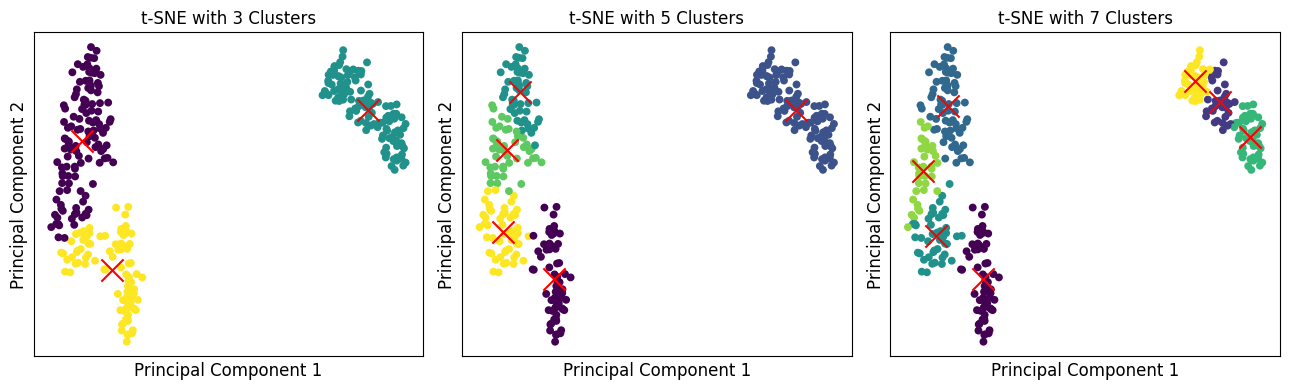

In [12]:
fig, axes = plt.subplots(1, 3, figsize=(13,4))

# left: clustering into 3 groups
axes[0].scatter(X_tsne_penguin[:,0], X_tsne_penguin[:,1], s=32, linewidth=0, c=clusters_kmeans_temp_3)
for x, y in kmeans_temp_3.cluster_centers_:
    axes[0].scatter(x, y, s=256, c='r', marker='x')
axes[0].set_title("t-SNE with 3 Clusters", fontsize=12)
axes[0].set_xlabel("Principal Component 1", fontsize=12)
axes[0].set_ylabel("Principal Component 2", fontsize=12)
axes[0].set_xticks([])
axes[0].set_yticks([])

# middle: clustering into 5 groups
axes[1].scatter(X_tsne_penguin[:,0], X_tsne_penguin[:,1], s=32, linewidth=0, c=clusters_kmeans_temp_5)
for x, y in kmeans_temp_5.cluster_centers_:
    axes[1].scatter(x, y, s=256, c='r', marker='x')
axes[1].set_title("t-SNE with 5 Clusters", fontsize=12)
axes[1].set_xlabel("Principal Component 1", fontsize=12)
axes[1].set_ylabel("Principal Component 2", fontsize=12)
axes[1].set_xticks([])
axes[1].set_yticks([])

# right: clustering into 7 groups
axes[2].scatter(X_tsne_penguin[:,0], X_tsne_penguin[:,1], s=32, linewidth=0, c=clusters_kmeans_temp_7)
for x, y in kmeans_temp_7.cluster_centers_:
    axes[2].scatter(x, y, s=256, c='r', marker='x')
axes[2].set_title("t-SNE with 7 Clusters", fontsize=12)
axes[2].set_xlabel("Principal Component 1", fontsize=12)
axes[2].set_ylabel("Principal Component 2", fontsize=12)
axes[2].set_xticks([])
axes[2].set_yticks([])

plt.tight_layout()
plt.show()

<div class='alert alert-warning'>

:::{warning}
It is noted that **t-SNE is primarily a visualization tool rather than a feature extraction method**, and **resulting embedding should not be used directly for downstream tasks (such as classification)**
- each time we run t-SNE, coordinates can change slightly due to randomness, even with same data
- as such, features produced by t-SNE may not be stable or meaningful for predictive modeling.
:::
</div>

## 5. UMAP

### 5.1 What is UMAP

UMAP (Uniform Manifold Approximation and Projection) is a non-linear dimensionality reduction technique
- it is based on **manifold learning** and **graph theory**
	- manifold learning means it assumes that even though data might have many dimensions, real structure of data lies on a lower-dimensional surface (like a curve or sheet) inside that high-dimensional space, and UMAP tries to find and keep that structure
	- graph theory means UMAP represents data as a graph
		- each point is a node, and connections (edges) show how close points are to each other
		- then it uses math to squeeze this graph down into 2D or 3D while keeping structure as much as possible
- it is similar in purpose to t-SNE, but with some key differences
	- it preserves both local and some global structure of data
    - generally faster and more scalable than t-SNE, especially for large datasets
    - can be used for visualization (2D/3D) or as **a preprocessing step for downstream tasks like clustering or classification**
- it constructs a high-dimensional graph representation of data and then projects it onto a low-dimensional space, by applying a series of optimization steps
	- this results in a visual representation of data that is both accurate and interpretable
- in comparison to PCA and t-SNE, UMAP offers a good balance of accuracy, efficiency, and scalability, making it a popular choice for dimensionality reduction in ML and DL tasks

### 5.2 Build a UMAP model

Following same procedure as in t-SNE subsection, we build and fit UMAP model, and visualize Penguins dataset in 2D, colored by species, island, and sex

In [13]:
import umap

umap_penguin = umap.UMAP(n_components = 2, n_neighbors=10)
X_umap_penguin = umap_penguin.fit_transform(X_scaled)

X_umap_penguin_species = penguins_dimR.join(pd.DataFrame(X_umap_penguin,
                                                         index = penguins_dimR.index,
                                                         columns = ['PC_1', 'PC_2']))
X_umap_penguin_species

,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex,PC_1,PC_2
0,Adelie,Torgersen,39.1,18.7,181.0,3750.0,Male,12.092779,6.094970
1,Adelie,Torgersen,39.5,17.4,186.0,3800.0,Female,12.579257,5.008840
2,Adelie,Torgersen,40.3,18.0,195.0,3250.0,Female,12.815824,4.844804
4,Adelie,Torgersen,36.7,19.3,193.0,3450.0,Female,12.595866,7.483640
5,Adelie,Torgersen,39.3,20.6,190.0,3650.0,Male,11.443077,8.832818
...,...,...,...,...,...,...,...,...,...
338,Gentoo,Biscoe,47.2,13.7,214.0,4925.0,Female,-4.147605,9.055198
340,Gentoo,Biscoe,46.8,14.3,215.0,4850.0,Female,-4.107390,8.724307
341,Gentoo,Biscoe,50.4,15.7,222.0,5750.0,Male,-4.172944,5.019638
342,Gentoo,Biscoe,45.2,14.8,212.0,5200.0,Female,-3.845546,7.865406


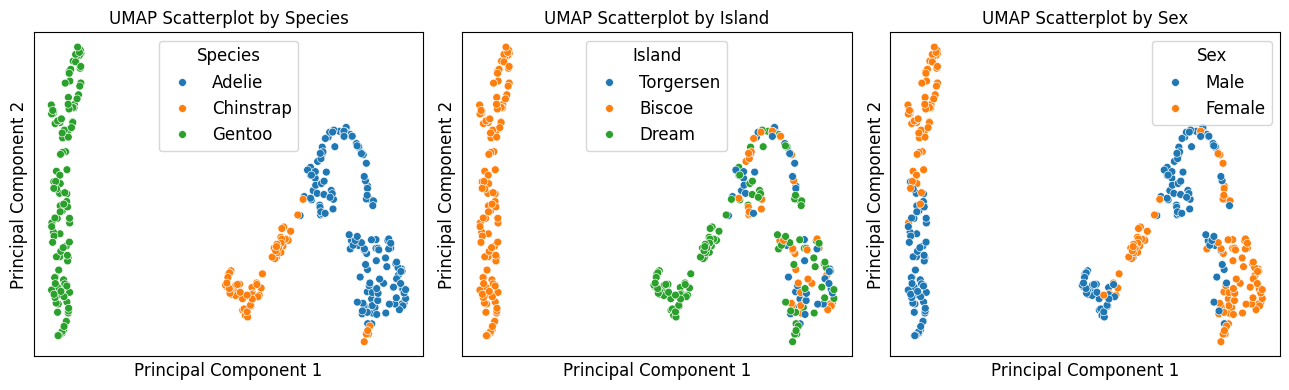

In [14]:
fig, axes = plt.subplots(1, 3, figsize=(13, 4))

# left subpolt: hua by species
sns.scatterplot(data=X_umap_penguin_species, x='PC_1', y='PC_2', hue='species', s=32, ax=axes[0])
axes[0].set_title("UMAP Scatterplot by Species", fontsize=12)
axes[0].set_xlabel("Principal Component 1", fontsize=12)
axes[0].set_ylabel("Principal Component 2", fontsize=12)
axes[0].legend(title="Species", fontsize=12, title_fontsize=12)
axes[0].set_xticks([])
axes[0].set_yticks([])

# middle subplot: hue by island
sns.scatterplot(data=X_umap_penguin_species, x='PC_1', y='PC_2', hue='island', s=32, ax=axes[1])
axes[1].set_title("UMAP Scatterplot by Island", fontsize=12)
axes[1].set_xlabel("Principal Component 1", fontsize=12)
axes[1].set_ylabel("Principal Component 2", fontsize=12)
axes[1].legend(title="Island", fontsize=12, title_fontsize=12)
axes[1].set_xticks([])
axes[1].set_yticks([])

# right subplot: hue by sex
sns.scatterplot(data=X_umap_penguin_species, x='PC_1', y='PC_2', hue='sex', s=32, ax=axes[2])
axes[2].set_title("UMAP Scatterplot by Sex", fontsize=12)
axes[2].set_xlabel("Principal Component 1", fontsize=12)
axes[2].set_ylabel("Principal Component 2", fontsize=12)
axes[2].legend(title="Sex", fontsize=12, title_fontsize=12)
axes[2].set_xticks([])
axes[2].set_yticks([])

plt.tight_layout()
plt.show()

Here we perform downstream clustering task using K-Means on a dataset reduced to two components obtained from UMAP model

In [15]:
kmeans_temp_3 = KMeans(n_clusters=3)
kmeans_temp_3.fit(X_umap_penguin)
kmeans_temp_3_clusters = kmeans_temp_3.predict(X_umap_penguin)

kmeans_temp_5 = KMeans(n_clusters=5)
kmeans_temp_5.fit(X_umap_penguin)
kmeans_temp_5_clusters = kmeans_temp_5.predict(X_umap_penguin)

kmeans_temp_7 = KMeans(n_clusters=7)
kmeans_temp_7.fit(X_umap_penguin)
kmeans_temp_7_clusters = kmeans_temp_7.predict(X_umap_penguin)

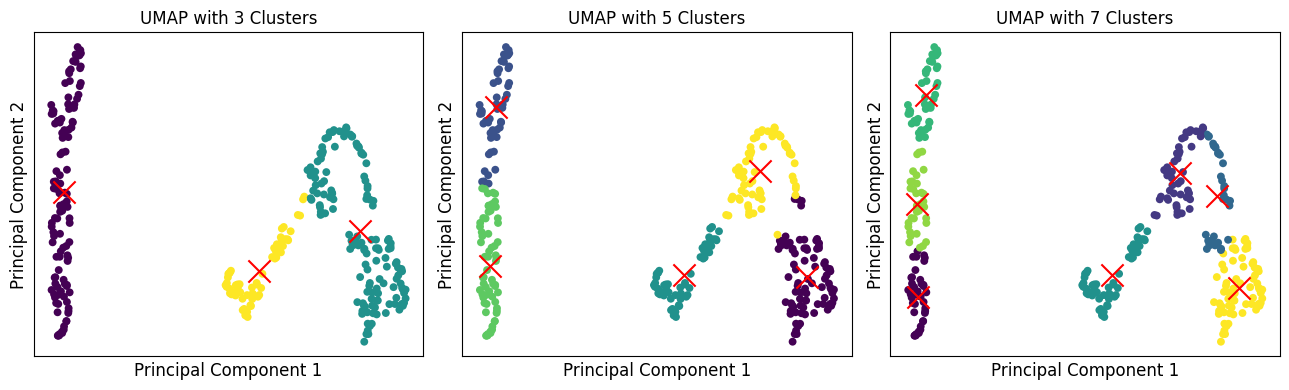

In [16]:
fig, axes = plt.subplots(1, 3, figsize=(13,4))

# left: clustering into 3 groups
axes[0].scatter(X_umap_penguin[:,0], X_umap_penguin[:,1], s=32, linewidth=0, c=kmeans_temp_3_clusters)
for x, y in kmeans_temp_3.cluster_centers_:
    axes[0].scatter(x, y, s=256, c='r', marker='x')
axes[0].set_title("UMAP with 3 Clusters", fontsize=12)
axes[0].set_xlabel("Principal Component 1", fontsize=12)
axes[0].set_ylabel("Principal Component 2", fontsize=12)
axes[0].set_xticks([])
axes[0].set_yticks([])

# middle: clustering into 5 groups
axes[1].scatter(X_umap_penguin[:,0], X_umap_penguin[:,1], s=32, linewidth=0, c=kmeans_temp_5_clusters)
for x, y in kmeans_temp_5.cluster_centers_:
    axes[1].scatter(x, y, s=256, c='r', marker='x')
axes[1].set_title("UMAP with 5 Clusters", fontsize=12)
axes[1].set_xlabel("Principal Component 1", fontsize=12)
axes[1].set_ylabel("Principal Component 2", fontsize=12)
axes[1].set_xticks([])
axes[1].set_yticks([])

# right: clustering into 7 groups
axes[2].scatter(X_umap_penguin[:,0], X_umap_penguin[:,1], s=32, linewidth=0, c=kmeans_temp_7_clusters)
for x, y in kmeans_temp_7.cluster_centers_:
    axes[2].scatter(x, y, s=256, c='r', marker='x')
axes[2].set_title("UMAP with 7 Clusters", fontsize=12)
axes[2].set_xlabel("Principal Component 1", fontsize=12)
axes[2].set_ylabel("Principal Component 2", fontsize=12)
axes[2].set_xticks([])
axes[2].set_yticks([])

plt.tight_layout()
plt.show()

## 6. Dimensionality Reduction on MNIST Dataset

### 6.1 MNIST dataset

MNIST (Modified National Institute of Standards and Technology) dataset is one of most widely used datasets in ML and CV
- it was created in 1998 by Yann LeCun, and contains contains a total of 70000 grayscale images of handwritten digits ranging from 0 to 9, and each image is a 28 × 28 pixel square, giving 784 features when flattened into a vector

In [17]:
from sklearn.datasets import fetch_openml

# download MNIST from OpenML
mnist = fetch_openml('mnist_784', version=1, as_frame=False)

# features and labels
features, labels = mnist.data, mnist.target
print(f"Number of samples (images): {features.shape[0]} \nNumber of features per sample (image): {features.shape[1]}\n")

# number of samples (images) for dimensionality reduction application
num_sample = 4000 
X, y = features[:num_sample], labels[:num_sample]

Number of samples (images): 70000 
Number of features per sample (image): 784



In [18]:
# data for 2nd image
print(X[1])

[  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
   0  51 159 253 159  50   0   0   0   0   0   0   0   0   0   0   0   0
   0   0   0   0   0   0   0   0   0   0  48 238 252 252 252 237   0   0
   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
   0  54 227 253 252 239 233 252  57   6   0   0   0   0   0   0   0   0
   0   0   0   0   0   0   0   0   0  10  60 224 252 253 252 202  84 252
 253 122   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
   0 163 252 252 252 253 252 252  96 189 253 167   

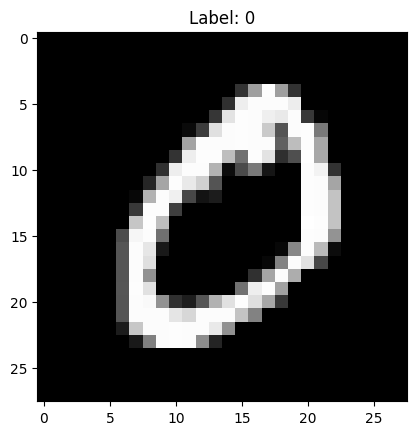

In [19]:
# show 2nd image
plt.imshow(X[1].reshape(28, 28), cmap="gray")
plt.title(f"Label: {y[1]}")
plt.show()

### 6.2 PCA

We first apply PCA on 784 features of 4000 grayscale images of handwritten digits and retai two most-major components
- it returns an array of 4000 x 2 where 2 columns are 1st and 2nd PCs of each grayscale images
- we plot these two PCs against each other

In [20]:
# PCA with 2 components
pca_mnist = PCA(n_components=2)
X_pca_mnist = pca_mnist.fit_transform(X)

print(X_pca_mnist.shape)

(4000, 2)


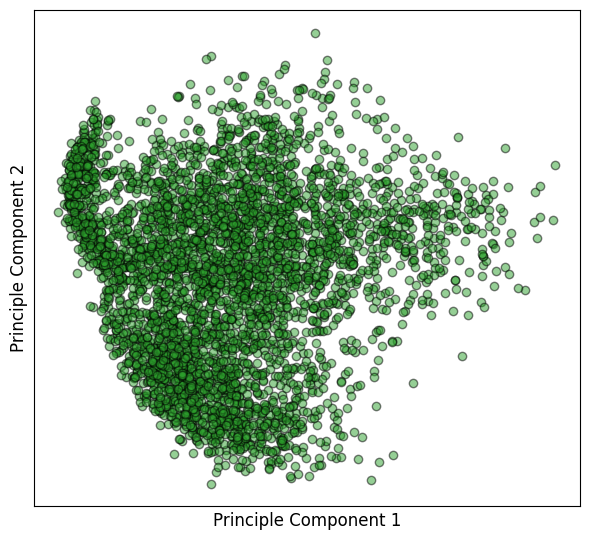

In [21]:
fig = plt.figure(figsize=(6, 5.5))
plt.scatter(X_pca_mnist[:, 0], X_pca_mnist[:, 1], c='tab:green', edgecolor='k', alpha=0.5)
plt.xlabel("Principle Component 1", fontsize = 12)
plt.ylabel("Principle Component 2", fontsize = 12)
plt.xticks([])
plt.yticks([])
plt.tight_layout()
plt.show()

Then we apply KMeans clustering algorithm to this 2D representation of MNIST dataset and compare resulting clusters with true image labels
- PCA has made a strong attempt to reduce dimensionality of MNIST dataset from 784D to 2D while preserving key structural information
- we can observe that digit 0 forms a reasonable pattern, but there is significant overlap among other digits

In [22]:
# apply clustering on PCA data
from sklearn.cluster import KMeans

kmean_pca_mnist = KMeans(n_clusters=10)
kmean_pca_mnist.fit(X_pca_mnist)
clusters_kmeans_pca_mnist = kmean_pca_mnist.predict(X_pca_mnist)

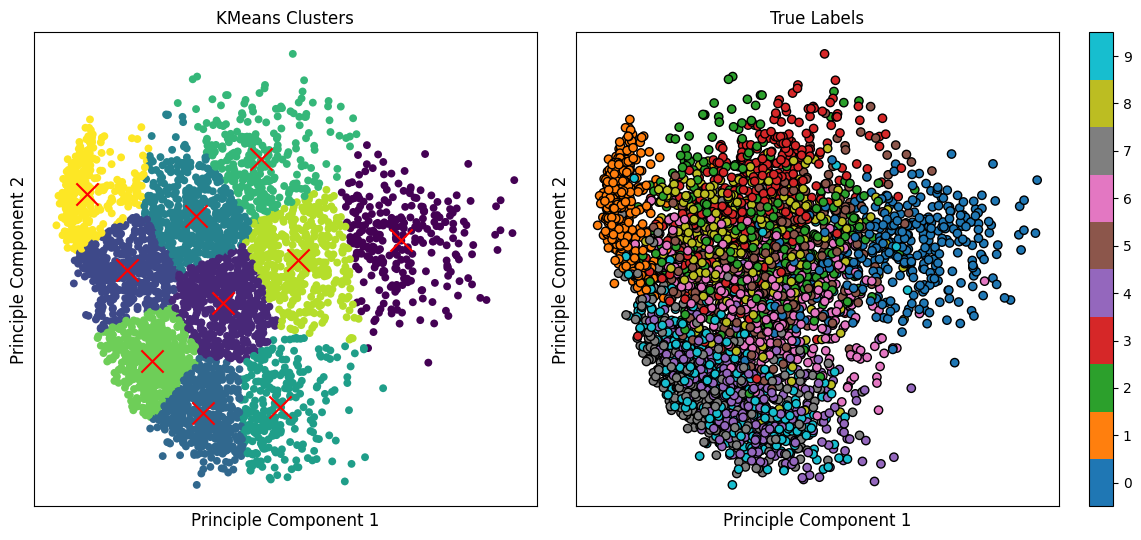

In [23]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5.5), 
    gridspec_kw={'width_ratios': [1, 1.2]}
)

# left: clustering results with cluster centers
axes[0].scatter(X_pca_mnist[:, 0], X_pca_mnist[:, 1], s=32, linewidth=0, c=clusters_kmeans_pca_mnist)
for cluster_x, cluster_y in kmean_pca_mnist.cluster_centers_:
    axes[0].scatter(cluster_x, cluster_y, s=256, c='r', marker='x')
axes[0].set_title("KMeans Clusters")
axes[0].set_xlabel("Principle Component 1", fontsize=12)
axes[0].set_ylabel("Principle Component 2", fontsize=12)
axes[0].set_xticks([])
axes[0].set_yticks([])

# right: true labels
labels_int = y.astype(int)
sc = axes[1].scatter(X_pca_mnist[:, 0], X_pca_mnist[:, 1], c=labels_int, cmap="tab10", edgecolor='k')
axes[1].set_title("True Labels")
axes[1].set_xlabel("Principle Component 1", fontsize=12)
axes[1].set_ylabel("Principle Component 2", fontsize=12)
axes[1].set_xticks([])
axes[1].set_yticks([])

cbar = plt.colorbar(sc, ax=axes[1], boundaries=np.arange(11)-0.5)
cbar.set_ticks(np.arange(10))

plt.tight_layout()
plt.show()

### 6.3 t-SNE

t-SNE algorithm is capable of capturing complex non-linear relationships in high-dimensional data
- we apply it to MNIST dataset to reduce its dimensionality (from 784D to 2D!) and visualize underlying structure of handwritten digits
- as t-SNE is an iterative algorithm that tries to position points in a low-dimensional space (*e.g.*, 2D), it needs an initial guess for where to start placing points
    - `init` in `TSNE(...)` class refers to how t-SNE initializes embedding before starting its optimization
    	- by default, it use **random initialization** (`init='random'`) to place points randomly in low-dimensional space
	- alternatively, it can use PCA initialization (`init='pca'`) as starting point to projects high-dimensional data down to `n_components` dimensions
		- PCA provides a more structured and stable starting point than random placement
		- it can lead to faster convergence and sometimes better preservation of global structure
		- it’s noted that PCA does not handle outlier data well primarily due to global preservation of structural information
		- therefore initializing t-SNE model with 'pca' can explicitly preserve global structures

In [24]:
tsne_mnist = TSNE(n_components=2, init='pca') # or 'random'  # initialising with "pca" explicitly preserves global structure
X_tsne_mnist = tsne_mnist.fit_transform(X)

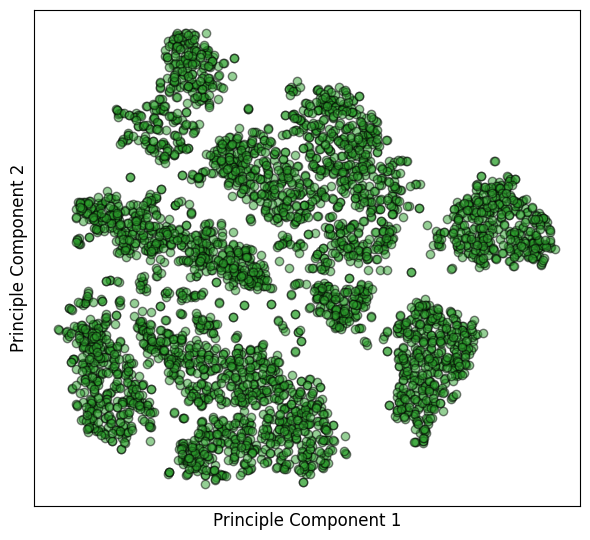

In [25]:
fig = plt.figure(figsize=(6, 5.5))
plt.scatter(X_tsne_mnist[:, 0], X_tsne_mnist[:, 1], c='tab:green', edgecolor='k', alpha=0.5)
plt.xlabel("Principle Component 1", fontsize = 12)
plt.ylabel("Principle Component 2", fontsize = 12)
plt.xticks([])
plt.yticks([])
plt.tight_layout()
plt.show()

With obtained t-SNE 2D representation of MNIST dataset, we apply K-Means clustering algorithm and compare resulting clusters with true image labels
- t-SNE method can separate digits 0, 1, 2, 6, 7, and 8 into clusters using a 2D representation (of 784D !) and a simple K-Means clustering algorithm

In [26]:
kmean_tsne_mnist = KMeans(n_clusters=10)
kmean_tsne_mnist.fit(X_tsne_mnist)
clusters_kmeans_tsne_mnist = kmean_tsne_mnist.predict(X_tsne_mnist)

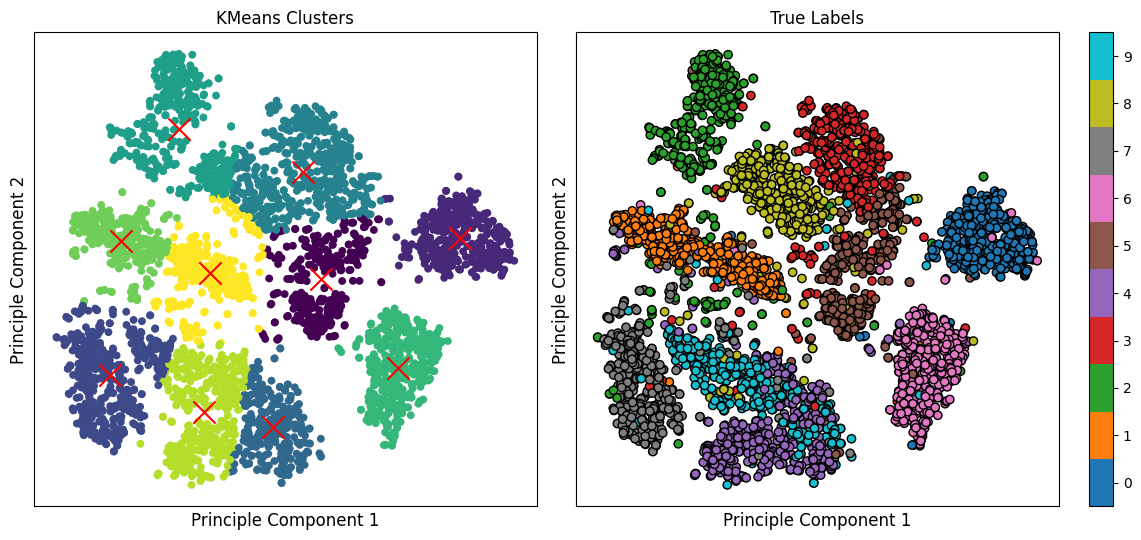

In [27]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5.5), 
    gridspec_kw={'width_ratios': [1, 1.2]}
)

# left: clustering results with cluster centers
axes[0].scatter(X_tsne_mnist[:, 0], X_tsne_mnist[:, 1], s=32, linewidth=0, c=clusters_kmeans_tsne_mnist)
for cluster_x, cluster_y in kmean_tsne_mnist.cluster_centers_:
    axes[0].scatter(cluster_x, cluster_y, s=256, c='r', marker='x')
axes[0].set_title("KMeans Clusters")
axes[0].set_xlabel("Principle Component 1", fontsize=12)
axes[0].set_ylabel("Principle Component 2", fontsize=12)
axes[0].set_xticks([])
axes[0].set_yticks([])

# right: true labels
sc = axes[1].scatter(X_tsne_mnist[:, 0], X_tsne_mnist[:, 1], c=labels_int, cmap="tab10", edgecolor='k')
axes[1].set_title("True Labels")
axes[1].set_xlabel("Principle Component 1", fontsize=12)
axes[1].set_ylabel("Principle Component 2", fontsize=12)
axes[1].set_xticks([])
axes[1].set_yticks([])

cbar = plt.colorbar(sc, ax=axes[1], boundaries=np.arange(11)-0.5)
cbar.set_ticks(np.arange(10))

plt.tight_layout()
plt.show()

### 6.3 UMAP

We apply UMAP algorithm to t-SNE representation to further refine embedding, potentially enhancing separation of clusters and revealing additional structure in data

In [28]:
umap_mnist = umap.UMAP(n_components = 2, n_neighbors=10, init=X_tsne_mnist) # init=X_pca or init=X_tsne or init='random'
X_umap_mnist = umap_mnist.fit_transform(X)

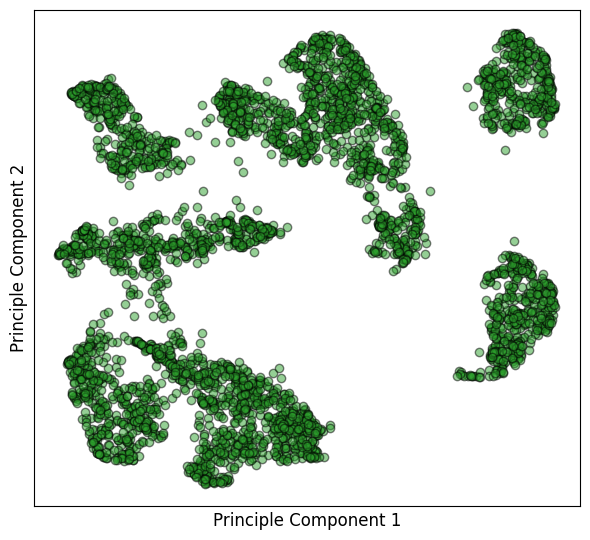

In [29]:
fig = plt.figure(figsize=(6, 5.5))
plt.scatter(X_umap_mnist[:, 0], X_umap_mnist[:, 1], c='tab:green', edgecolor='k', alpha=0.5)
plt.xlabel("Principle Component 1", fontsize = 12)
plt.ylabel("Principle Component 2", fontsize = 12)
plt.xticks([])
plt.yticks([])

plt.tight_layout()
plt.show()

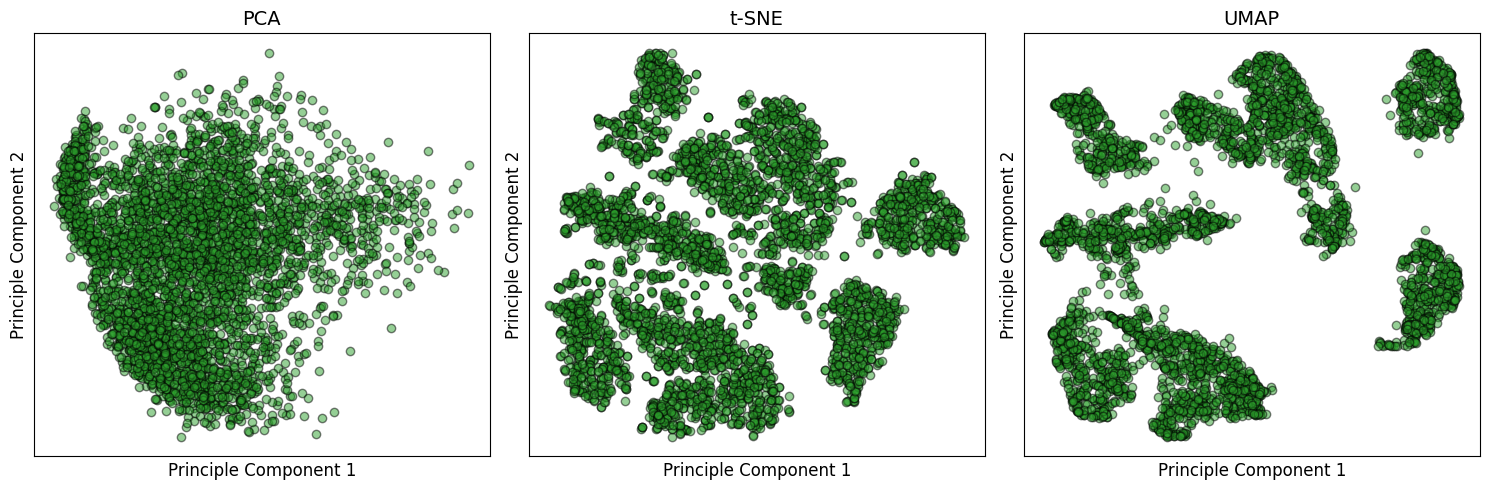

In [30]:
X_list = [X_pca_mnist, X_tsne_mnist, X_umap_mnist]
titles = ["PCA", "t-SNE", "UMAP"]

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

for i, ax in enumerate(axes):
    ax.scatter(X_list[i][:, 0], X_list[i][:, 1], c='tab:green', edgecolor='k', alpha=0.5)
    ax.set_title(titles[i], fontsize=14)
    ax.set_xlabel("Principle Component 1", fontsize=12)
    ax.set_ylabel("Principle Component 2", fontsize=12)
    ax.set_xticks([])
    ax.set_yticks([])
plt.tight_layout()
plt.show()

With obtained UMAP 2D representation of MNIST dataset, we apply K-Means clustering algorithm and compare resulting clusters with true image labels

In [31]:
kmean_umap_mnist = KMeans(n_clusters=10)
kmean_umap_mnist.fit(X_umap_mnist)
clusters_kmeans_umap_mnist = kmean_umap_mnist.predict(X_umap_mnist)

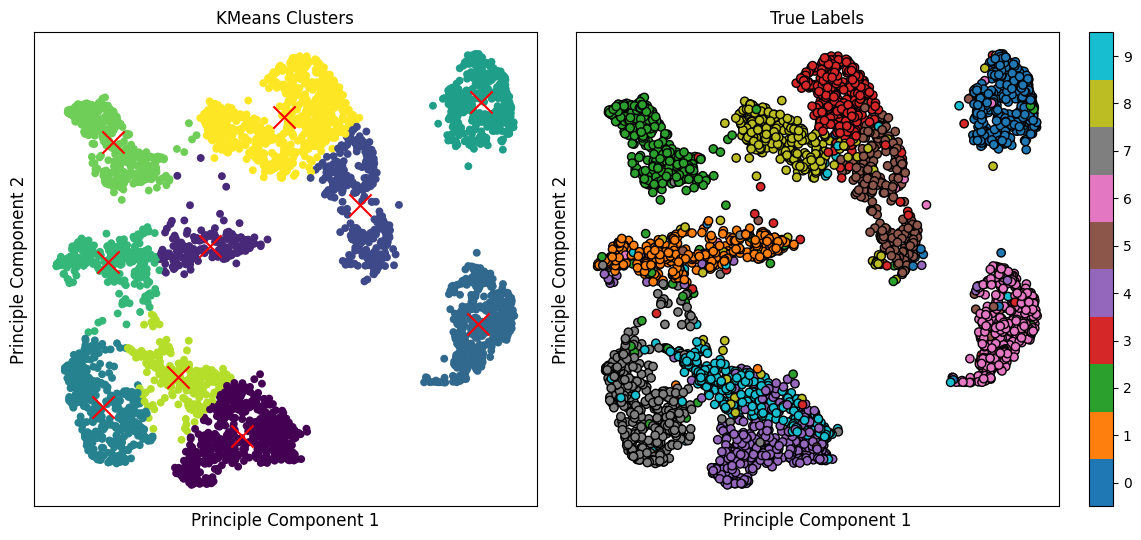

In [32]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5.5), 
    gridspec_kw={'width_ratios': [1, 1.2]}
)

# left: clustering results with cluster centers
axes[0].scatter(X_umap_mnist[:, 0], X_umap_mnist[:, 1], s=32, linewidth=0, c=clusters_kmeans_umap_mnist)
for cluster_x, cluster_y in kmean_umap_mnist.cluster_centers_:
    axes[0].scatter(cluster_x, cluster_y, s=256, c='r', marker='x')
axes[0].set_title("KMeans Clusters")
axes[0].set_xlabel("Principle Component 1", fontsize=12)
axes[0].set_ylabel("Principle Component 2", fontsize=12)
axes[0].set_xticks([])
axes[0].set_yticks([])

# right: true labels
sc = axes[1].scatter(X_umap_mnist[:, 0], X_umap_mnist[:, 1], c=labels_int, cmap="tab10", edgecolor='k')
axes[1].set_title("True Labels")
axes[1].set_xlabel("Principle Component 1", fontsize=12)
axes[1].set_ylabel("Principle Component 2", fontsize=12)
axes[1].set_xticks([])
axes[1].set_yticks([])

cbar = plt.colorbar(sc, ax=axes[1], boundaries=np.arange(11)-0.5)
cbar.set_ticks(np.arange(10))

plt.tight_layout()
plt.show()

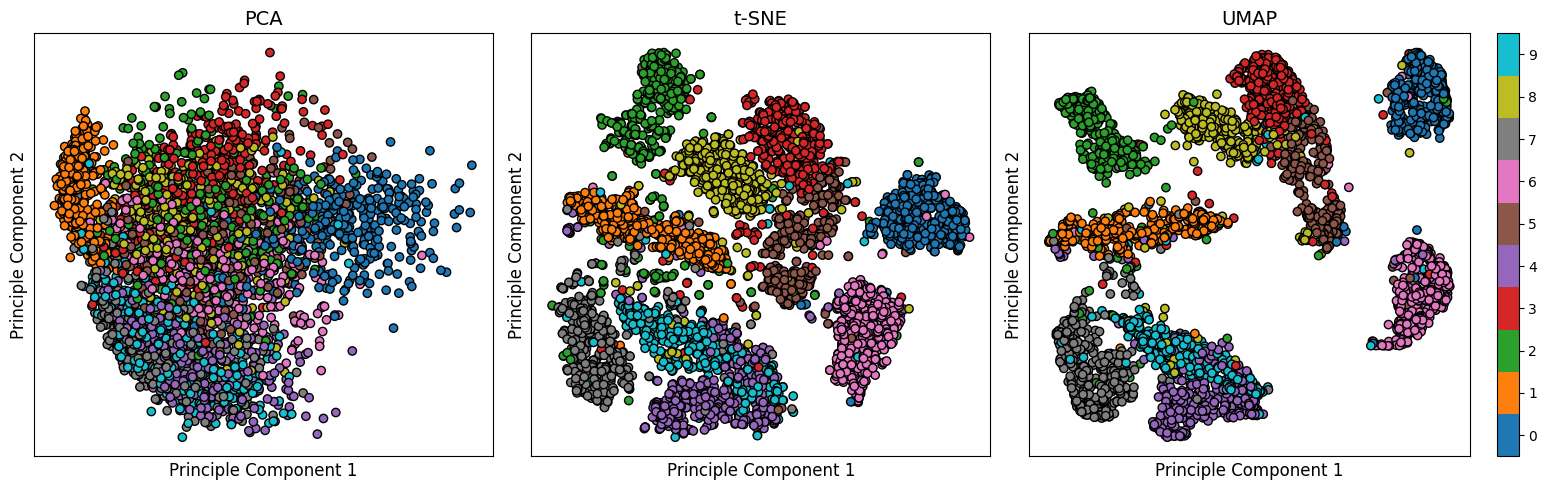

In [33]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5), 
    gridspec_kw={'width_ratios': [1, 1, 1.2]}
)

# left: true labels on PCA dataset
sc = axes[0].scatter(X_pca_mnist[:, 0], X_pca_mnist[:, 1], c=labels_int, cmap="tab10", edgecolor='k')
axes[0].set_title("PCA", fontsize=14)
axes[0].set_xlabel("Principle Component 1", fontsize=12)
axes[0].set_ylabel("Principle Component 2", fontsize=12)
axes[0].set_xticks([])
axes[0].set_yticks([])

# middle: true labels on t-SNE datset
sc = axes[1].scatter(X_tsne_mnist[:, 0], X_tsne_mnist[:, 1], c=labels_int, cmap="tab10", edgecolor='k')
axes[1].set_title("t-SNE", fontsize=14)
axes[1].set_xlabel("Principle Component 1", fontsize=12)
axes[1].set_ylabel("Principle Component 2", fontsize=12)
axes[1].set_xticks([])
axes[1].set_yticks([])

# right: true labels on UMAP datset
sc = axes[2].scatter(X_umap_mnist[:, 0], X_umap_mnist[:, 1], c=labels_int, cmap="tab10", edgecolor='k')
axes[2].set_title("UMAP", fontsize=14)
axes[2].set_xlabel("Principle Component 1", fontsize=12)
axes[2].set_ylabel("Principle Component 2", fontsize=12)
axes[2].set_xticks([])
axes[2].set_yticks([])

cbar = plt.colorbar(sc, ax=axes[2], boundaries=np.arange(11)-0.5)
cbar.set_ticks(np.arange(10))

plt.tight_layout()
plt.show()

A comparison of 2D embeddings shows that UMAP produces a clearer and more well-separated clustering of data than t-SNE, while t-SNE in turn captures structure of data more effectively than PCA, this suggests that
- UMAP is generally better at preserving both local and global patterns
- t-SNE excels at local neighborhood structure
- PCA, while useful for linear dimensionality reduction, is less effective in revealing complex non-linear relationships

<div class='alert alert-info'>

:::{keypoints}
- Representative dimensionality reduction methods include PCA, t-SNE, and UMAP.
- PCA is a method to reduce dimensions via creating new variables called PCs, which are **linear** combinations of original features
- T-SNE and UMAP are both **nonlinear** dimensionality reduction methods to reduce high-dimensional data to 2D or 3D
	- T-SNE focuses on keeping similar points close and dissimilar points apart in lower-dimensional space, but **not applicable for predictive modeling**
	- UMAP preserves both local relationships (nearby points stay close) and some global structure, scales well to large datasets, and **can perform downstream tasks like clustering and classification**
- We first applied these algorithms to Penguins dataset and then to MNIST dataset to evaluate their ability to reduce dimensionality while preserving essential information needed for clustering
:::
</div>